### Step 0 :- Import Libraries

In [1]:
# Import Pandas
import pandas as pd

# Import NumPy
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt

# Import train-test split
from sklearn.model_selection import train_test_split

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Import model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

### Step 1 :- Load Dataset

In [2]:
# Load dataset
weather_data = pd.read_csv('humidity.csv')

#### Display Dataset Information

In [3]:
# Display dataset shape
print(f'Dataset Shape: {weather_data.shape}')

# Display column names
print(f'\nColumns:\n{weather_data.columns}')

# Display first 5 rows
weather_data.head()

Dataset Shape: (701548, 6)

Columns:
Index(['sensor_id', 'lat', 'lon', 'pressure', 'temperature', 'humidity'], dtype='str')


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


#### Check Dataset Information

In [4]:
# Display dataset information
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


### Step 2 :- Exploratory Data Analysis

#### Display First 5 Rows

In [5]:
# Display first 5 rows
weather_data.head()

,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


#### Display Last 5 Rows

In [6]:
# Display last 5 rows
weather_data.tail()

,sensor_id,lat,lon,pressure,temperature,humidity
701543,3558,42.671,23.364,95562.08,21.99,52.28
701544,3836,42.702,23.371,96070.06,21.41,56.84
701545,3296,42.671,23.325,95230.42,22.53,51.72
701546,2234,42.685,23.356,95653.14,23.01,49.78
701547,2232,42.685,23.301,95418.48,22.57,51.44


#### Check Dataset Shape

In [7]:
# Display dataset shape
print(f'Rows: {weather_data.shape[0]}')

print(f'Columns: {weather_data.shape[1]}')

Rows: 701548
Columns: 6


#### Check Data Types

In [8]:
# Display data types
weather_data.dtypes

sensor_id        int64
lat            float64
lon            float64
pressure       float64
temperature    float64
humidity       float64
dtype: object

#### Check Missing Values

In [9]:
# Display missing values
weather_data.isnull().sum()

sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64

#### Check Duplicate Records

In [10]:
# Display duplicate records
print(f'Duplicate Records: {weather_data.duplicated().sum()}')

Duplicate Records: 4035


#### Display Summary Statistics

In [11]:
# Display summary statistics
weather_data.describe()

,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


#### Display Feature Names

In [12]:
# Display column names
weather_data.columns

Index(['sensor_id', 'lat', 'lon', 'pressure', 'temperature', 'humidity'], dtype='str')

#### Target Variable Summary

In [13]:
# Display temperature summary
weather_data['temperature'].describe()

count    701548.000000
mean         24.754990
std          14.013001
min        -145.120000
25%          20.630000
50%          24.780000
75%          29.870000
max          61.170000
Name: temperature, dtype: float64

#### Feature Variable Summary

In [14]:
# Display humidity summary
weather_data['humidity'].describe()

count    701548.000000
mean         48.348949
std          20.907247
min           0.000000
25%          34.140000
50%          48.350000
75%          62.940000
max         100.000000
Name: humidity, dtype: float64

#### Scatter Plot

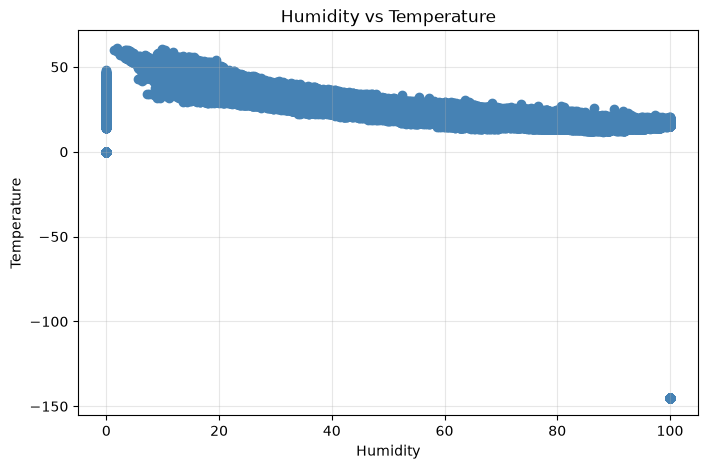

In [15]:
# Create scatter plot
plt.figure(figsize = (8, 5))

plt.scatter(

    weather_data['humidity'],

    weather_data['temperature'],

    color = 'steelblue')

plt.title('Humidity vs Temperature')

plt.xlabel('Humidity')

plt.ylabel('Temperature')

plt.grid(alpha = 0.3)

plt.show()

### Step 3 :- Data Preprocessing

#### Remove Missing Values

In [16]:
# Remove missing values
weather_data = weather_data.dropna()

# Display dataset shape
print(f'Dataset Shape: {weather_data.shape}')

Dataset Shape: (701548, 6)


#### Remove Duplicate Records

In [17]:
# Remove duplicate records
weather_data = weather_data.drop_duplicates()

# Display duplicate records
print(f'Duplicate Records: {weather_data.duplicated().sum()}')

Duplicate Records: 0


#### Select Input Feature

In [18]:
# Select input feature
X = weather_data[['humidity']]

X.head()

,humidity
0,62.48
1,59.46
2,44.38
3,38.28
4,46.37


#### Select Target Variable

In [19]:
# Select target variable
y = weather_data['temperature']

y.head()

0    23.46
1    23.06
2    26.53
3    28.34
4    26.31
Name: temperature, dtype: float64

#### Split Dataset

In [20]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size = 0.2,

    random_state = 42)

#### Display Dataset Shape

In [21]:
# Display dataset shape
print(f'Training Data: {X_train.shape}')

print(f'Testing Data: {X_test.shape}')

Training Data: (558010, 1)
Testing Data: (139503, 1)


#### Verify Training Data

In [22]:
# Display training data
X_train.head()

,humidity
41226,81.77
647388,52.80
324930,67.61
229651,0.00
188944,74.83


#### Verify Testing Data

In [23]:
# Display testing data
X_test.head()

,humidity
378217,70.92
346977,53.36
619020,53.69
254340,59.05
480385,25.74


### Step 4 :- Model Training

#### Create Linear Regression Model

In [24]:
# Create Linear Regression model
linear_regression_model = LinearRegression()

#### Train Model

In [25]:
# Train model
linear_regression_model.fit(

    X_train,

    y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['humidity']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


#### Display Model Coefficient

In [26]:
# Display model coefficient
print(

    f'Coefficient: {linear_regression_model.coef_[0]:.4f}')

Coefficient: -0.2422


#### Display Model Intercept

In [27]:
# Display model intercept
print(

    f'Intercept: {linear_regression_model.intercept_:.4f}')

Intercept: 37.3242


#### Predict Temperature

In [28]:
# Predict temperature
predicted_temperature = linear_regression_model.predict(

    X_test)

predicted_temperature[:10]

array([20.14403845, 24.39790094, 24.31795933, 23.01951383, 31.08877122,
       24.64983813, 25.17551476, 28.39255883, 29.22588952, 17.71187561])

#### Compare Actual vs Predicted Values

In [29]:
# Compare actual and predicted values
prediction_results = pd.DataFrame({

    'Actual Temperature': y_test.values,

    'Predicted Temperature': predicted_temperature})

prediction_results.head(10)

,Actual Temperature,Predicted Temperature
0,18.81,20.144038
1,21.68,24.397901
2,20.59,24.317959
3,22.29,23.019514
4,35.02,31.088771
5,22.05,24.649838
6,27.99,25.175515
7,26.98,28.392559
8,31.09,29.225890
9,19.81,17.711876


#### Display Number of Predictions

In [30]:
# Display prediction count
print(

    f'Total Predictions: {len(predicted_temperature)}')

Total Predictions: 139503


### Step 5 :- Model Evaluation

#### Calculate Mean Absolute Error (MAE)

In [31]:
# Calculate Mean Absolute Error
mean_absolute_error_value = mean_absolute_error(

    y_test,

    predicted_temperature)

print(

    f'Mean Absolute Error: {mean_absolute_error_value:.2f}')

Mean Absolute Error: 2.75


#### Calculate Mean Squared Error (MSE)

In [32]:
# Calculate Mean Squared Error
mean_squared_error_value = mean_squared_error(

    y_test,

    predicted_temperature)

print(

    f'Mean Squared Error: {mean_squared_error_value:.2f}')

Mean Squared Error: 16.79


#### Calculate Root Mean Squared Error (RMSE)

In [33]:
# Calculate Root Mean Squared Error
root_mean_squared_error = np.sqrt(

    mean_squared_error_value)

print(

    f'Root Mean Squared Error: {root_mean_squared_error:.2f}')

Root Mean Squared Error: 4.10


#### Calculate R² Score

In [34]:
# Calculate R² Score
r2_score_value = r2_score(

    y_test,

    predicted_temperature)

print(

    f'R² Score: {r2_score_value:.4f}')

R² Score: 0.5973


#### Display Model Performance

In [35]:
# Display model performance
model_performance = pd.DataFrame({

    'Metric': [

        'Mean Absolute Error',

        'Mean Squared Error',

        'Root Mean Squared Error',

        'R² Score'],

    'Value': [

        mean_absolute_error_value,

        mean_squared_error_value,

        root_mean_squared_error,

        r2_score_value]})

model_performance

,Metric,Value
0,Mean Absolute Error,2.751993
1,Mean Squared Error,16.794794
2,Root Mean Squared Error,4.098145
3,R² Score,0.597338


#### Model Accuracy

In [36]:
# Display model accuracy
print(

    f'Model Accuracy: {r2_score_value * 100:.2f}%')

Model Accuracy: 59.73%


### Step 6 :- Prediction

#### Predict Temperature for Test Data

In [37]:
# Predict temperature
predicted_temperature = linear_regression_model.predict(

    X_test)

predicted_temperature[:10]

array([20.14403845, 24.39790094, 24.31795933, 23.01951383, 31.08877122,
       24.64983813, 25.17551476, 28.39255883, 29.22588952, 17.71187561])

#### Compare Actual vs Predicted Temperature

In [38]:
# Compare actual and predicted temperature
prediction_results = pd.DataFrame({

    'Actual Temperature': y_test.values,

    'Predicted Temperature': predicted_temperature})

prediction_results.head(10)

,Actual Temperature,Predicted Temperature
0,18.81,20.144038
1,21.68,24.397901
2,20.59,24.317959
3,22.29,23.019514
4,35.02,31.088771
5,22.05,24.649838
6,27.99,25.175515
7,26.98,28.392559
8,31.09,29.225890
9,19.81,17.711876


#### Predict New Temperature

In [39]:
# New humidity value
new_humidity = pd.DataFrame({

    'humidity': [60]})

# Predict temperature
predicted_value = linear_regression_model.predict(

    new_humidity)

print(

    f'Predicted Temperature: {predicted_value[0]:.2f}')

Predicted Temperature: 22.79


#### Predict Multiple Temperatures

In [40]:
# New humidity values
new_humidity = pd.DataFrame({

    'humidity': [

        30,

        50,

        70,

        90]})

# Predict temperature
predicted_temperature = linear_regression_model.predict(

    new_humidity)

# Display prediction results
prediction_table = new_humidity.copy()

prediction_table['Predicted Temperature'] = predicted_temperature

prediction_table

,humidity,Predicted Temperature
0,30,30.056798
1,50,25.211852
2,70,20.366906
3,90,15.521960


#### Prediction Summary

In [41]:
# Display total predictions
print(

    f'Total Predictions: {len(predicted_temperature)}')

Total Predictions: 4


### Step 7 :- Visualization

#### Actual vs Predicted Temperature

In [42]:
# Predict temperature for the test dataset
predicted_temperature = linear_regression_model.predict(X_test)

# Check shapes
print("y_test shape:", y_test.shape)
print("predicted_temperature shape:", predicted_temperature.shape)

y_test shape: (139503,)
predicted_temperature shape: (139503,)


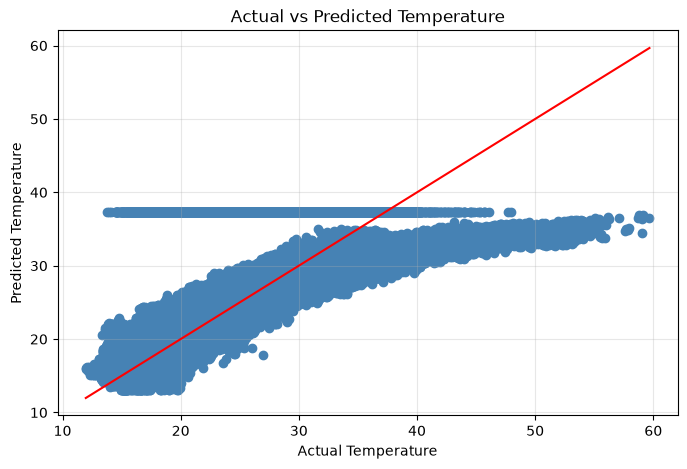

In [43]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot actual temperature
plt.scatter(

    y_test,

    predicted_temperature,

    color = 'steelblue')

# Plot reference line
plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color = 'red')

# Chart title
plt.title('Actual vs Predicted Temperature')

# X-axis label
plt.xlabel('Actual Temperature')

# Y-axis label
plt.ylabel('Predicted Temperature')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Regression Line

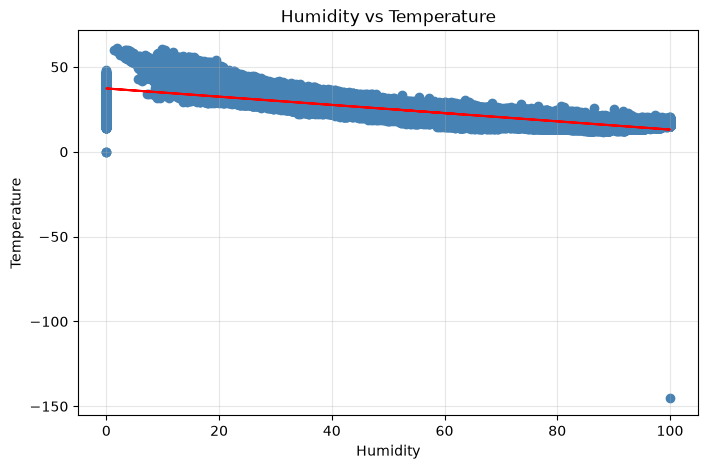

In [44]:
# Create figure
plt.figure(figsize = (8, 5))

# Scatter plot
plt.scatter(

    weather_data['humidity'],

    weather_data['temperature'],

    color = 'steelblue')

# Regression line
plt.plot(

    weather_data['humidity'],

    linear_regression_model.predict(X),

    color = 'red')

# Chart title
plt.title('Humidity vs Temperature')

# X-axis label
plt.xlabel('Humidity')

# Y-axis label
plt.ylabel('Temperature')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Prediction Comparison

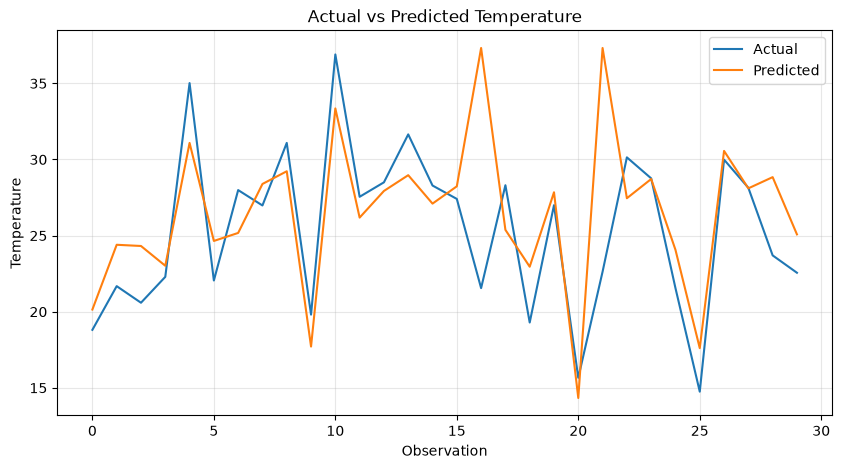

In [45]:
# Create figure
plt.figure(figsize = (10, 5))

# Plot actual values
plt.plot(

    y_test.values[:30],

    label = 'Actual')

# Plot predicted values
plt.plot(

    predicted_temperature[:30],

    label = 'Predicted')

# Chart title
plt.title('Actual vs Predicted Temperature')

# X-axis label
plt.xlabel('Observation')

# Y-axis label
plt.ylabel('Temperature')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Residual Plot

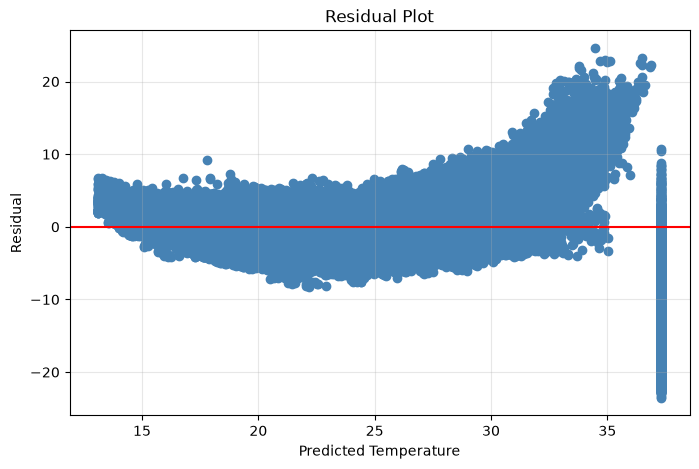

In [46]:
# Calculate residuals
residuals = y_test - predicted_temperature

# Create figure
plt.figure(figsize = (8, 5))

# Scatter plot
plt.scatter(

    predicted_temperature,

    residuals,

    color = 'steelblue')

# Reference line
plt.axhline(

    y = 0,

    color = 'red')

# Chart title
plt.title('Residual Plot')

# X-axis label
plt.xlabel('Predicted Temperature')

# Y-axis label
plt.ylabel('Residual')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Model Performance Summary

In [47]:
# Display model performance
model_performance

,Metric,Value
0,Mean Absolute Error,2.751993
1,Mean Squared Error,16.794794
2,Root Mean Squared Error,4.098145
3,R² Score,0.597338


### Step 8 :- Information

> Dataset: Weather Temperature Prediction

> Source File:
> - humidity.csv

> Machine Learning Algorithm:
> - Linear Regression

> Input Feature:
> - Humidity

> Target Variable:
> - Temperature

> Rows: 697,513

> Columns: 6

> Data Preprocessing:
> - Missing values were removed.
> - Duplicate records were removed.
> - Input and target variables were selected.
> - Dataset was split into training and testing sets (80% : 20%).

> Model Evaluation Metrics:
> - Mean Absolute Error (MAE)
> - Mean Squared Error (MSE)
> - Root Mean Squared Error (RMSE)
> - R² Score

### Step 9 :- Data Insights

> The final dataset contains 697,513 records after removing duplicate rows.

> The dataset includes 6 features related to weather conditions.

> The average temperature is 24.75°C.

> The average humidity is 48.35%.

> Humidity values range from 0% to 100%.

> The Linear Regression model achieved an R² Score of 59.73%.

> The model recorded a Mean Absolute Error (MAE) of 2.75°C.

> The Root Mean Squared Error (RMSE) is 4.10°C, indicating a moderate prediction error.

> The regression coefficient is negative (-0.2422), indicating that temperature generally decreases as humidity increases.

### Step 10 :- Model Insights

> The Linear Regression model successfully learned the relationship between humidity and temperature.

> The model achieved an R² Score of 59.73%, indicating that humidity explains a moderate portion of the variation in temperature.

> The regression coefficient is negative (-0.2422), showing that temperature generally decreases as humidity increases.

> The Mean Absolute Error (MAE) is 2.75°C, indicating that the average prediction error is relatively small.

> The Root Mean Squared Error (RMSE) is 4.10°C, showing that most predictions are reasonably close to the actual temperature.

> The model can be used for basic temperature prediction based on humidity values.

### Step 11 :- Risks

> The model uses only humidity to predict temperature, so other weather factors are not considered.

> The prediction accuracy is moderate (R² Score: 59.73%), which means some temperature variations are not explained by the model.

> Extreme weather conditions may reduce prediction accuracy.

> Incorrect or noisy sensor data can affect model performance.

> The model may not perform well on data that is very different from the training dataset.

### Step 12 :- Opportunities

> Add more weather features such as pressure, latitude, and longitude to improve prediction accuracy.

> Train the model using a larger and more diverse dataset for better generalization.

> Compare Linear Regression with other machine learning algorithms to improve performance.

> Use the model in weather monitoring and forecasting applications.

> Continuously update the model with new weather data to maintain prediction accuracy.

### Step 13 :- Recommendations

> Include additional weather features such as pressure, latitude, and longitude to improve prediction accuracy.

> Regularly update the model with new weather data to maintain reliable predictions.

> Monitor model performance using evaluation metrics such as MAE, RMSE, and R² Score.

> Validate the quality of sensor data before making predictions.

> Compare the Linear Regression model with other machine learning algorithms to identify the best-performing model.

### Step 14 :- Future Improvements

> Add more weather features to improve prediction accuracy.

> Collect more historical weather data for better model training.

> Test different machine learning algorithms and compare their performance.

> Perform feature engineering to identify the most important variables.

> Deploy the trained model as a simple web application for real-time temperature prediction.